# Bayesian Optimisation for Machine Learning

**STAT 238 Final Project · UC Berkeley Spring 2026**

---

Machine learning models are only as good as their hyperparameters.  Choosing them well can be the difference between a model that works and one that does not — yet every evaluation of a candidate configuration requires a full training run, which can take minutes or hours on GPU.  

This project applies **Bayesian Optimisation (BO)**, a principled framework for optimising expensive black-box functions, to two real ML problems and benchmarks it against standard search strategies.

## 1  The Problem

### Hyperparameter tuning is expensive

Consider tuning an NCF model on MovieLens 1M with five hyperparameters: embedding dimension, MLP architecture, learning rate, L2 regularisation, and a confidence-weighting scale.  A single evaluation — one complete training run — costs roughly **22 minutes on an RTX 2080 Ti GPU**.

| Search strategy | Evaluations needed | GPU time |
|---|---|---|
| Grid search (4 levels per dim, 5 dims) | $4^5 = 1{,}024$ | **≈ 341 hours** |
| Random search (matched budget) | 15 | ≈ 5.5 hours |
| **Bayesian Optimisation (this project)** | **15** | **≈ 5.5 hours** |

Random search uses the same budget as BO but has **no memory**: trial 14 learns nothing from trials 1–13.

### What makes this hard

* **No gradient** — we cannot back-propagate through a training run to find the optimal learning rate or architecture.
* **Noisy evaluations** — the same configuration trained twice may give slightly different NDCG values due to random initialisation.
* **Mixed parameter types** — some parameters are continuous (lr, l2), others are discrete ordinal (embedding dim, MLP depth).
* **Tight budget** — on a shared academic GPU cluster, 15–60 evaluations is realistic; hundreds are not.

## 2  Our Approach: Bayesian Optimisation

BO treats the objective $f$ as a random function and maintains a **Gaussian Process** surrogate that encodes everything learned from past evaluations.  At each step it asks: *where should I evaluate next to maximally improve on the best result so far?*

The answer is given by the **Expected Improvement (EI)** acquisition function, which balances exploitation (evaluate where the GP thinks $f$ is high) with exploration (evaluate where the GP is most uncertain).

```
Algorithm: Bayesian Optimisation
─────────────────────────────────────────────────────────────
1.  Evaluate f at n_init random configurations  →  dataset D
2.  For t = n_init + 1, …, T:
    a.  Fit GP on D                      ← cheap surrogate of f
    b.  x_t = argmax_{x} EI(x ; GP)     ← acquisition step
    c.  y_t = f(x_t)                     ← expensive evaluation
    d.  D  ←  D ∪ {(x_t, y_t)}
3.  Return x* = argmax_t y_t
─────────────────────────────────────────────────────────────
```

**Implementation** (in `src/`):

| Module | What it does |
|---|---|
| `src/gp.py` | GP with SE kernel, Cholesky solver, marginal-likelihood hyperparameter fitting |
| `src/acquisition.py` | EI closed-form + L-BFGS-B maximisation over the unit cube |
| `src/bo.py` | BO loop — random init, GP conditioning, EI maximisation, result logging |
| `src/black_box_ncf.py` | Wraps NCF training; appends results to `results/ncf/trials.csv` |
| `src/black_box_upworthy.py` | Computes ANOVA F-stat; appends results to `results/upworthy/*.csv` |

## 3  Experiment 1 — NCF Hyperparameter Tuning

**Context:** A concurrent CS 289A project compares recommendation algorithms (matrix factorisation, NCF, two-stage ranker) on MovieLens 1M as training data sparsity increases.  Before the sparsity sweep can run *fairly*, NCF needs its five hyperparameters fixed on the full dataset.

**Parameter space (5-D):**

| Parameter | Range | Encoding |
|---|---|---|
| Embedding dim | $\{32, 64, 128, 256\}$ | ordinal |
| MLP architecture | 3 configs | ordinal |
| Learning rate $\eta$ | $[10^{-4},\,10^{-2}]$ | $\log\eta$ |
| L2 weight decay $\lambda$ | $[10^{-6},\,10^{-3}]$ | $\log\lambda$ |
| WMF confidence scale $\alpha$ | $[0.5,\,5.0]$ | as-is |

**Objective:** validation NDCG@10 (higher is better).

**Setup:** 5 random initialisations + 10 EI-guided BO steps, run on SCF GPU cluster (RTX 2080 Ti, 10 epochs per trial, ~22 min each).

**Result:**

> BO improved NDCG@10 from **0.3745** (best of 5 random trials) to **0.4056** in just 10 additional steps — a **+8.3 % relative gain** — and identified that large embedding dim (256), deep MLP ([256, 128, 64, 32]), very low L2 ($10^{-6}$), and a low learning rate ($7\times10^{-4}$) are the critical choices.

*Details and plots in `01_ncf_bo.ipynb`.*

## 4  Experiment 2 — Upworthy Classifier Threshold Tuning

**Context:** The Upworthy Research Archive contains ~22k A/B headline tests.
A zero-shot NLI classifier assigns each headline to a content category.  The quality of downstream statistical tests (comparing click-through rates across categories) depends heavily on two thresholds that control classifier behaviour.

**Parameter space (2-D):**

| Parameter | Range | Encoding |
|---|---|---|
| Confidence threshold | $[0.05,\,0.90]$ | as-is |
| Minimum category size | $[10,\,400]$ headlines | $\log$ |

**Objective:** one-way ANOVA F-statistic across categories (measures how meaningfully categories differ in click-through rate; higher = better separation).

**Setup:** all three methods run locally (milliseconds per trial); 60-trial budget each.

**Result:**

> BO found the highest F-statistic of all three methods:
> **BO 1568.7 > Random Search 1514.0 > Grid Search 1435.2**.
> BO converged to its best result in roughly half the budget of random search.

*Details and plots in `02_upworthy_bo.ipynb`.*

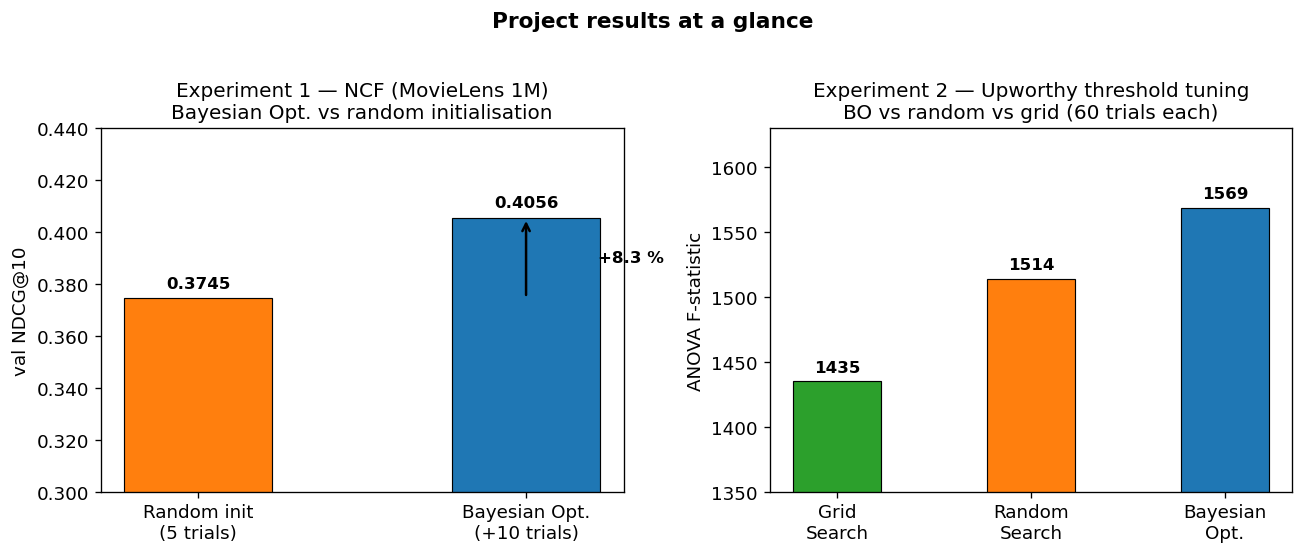

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "figure.dpi": 120})

# ── Summary figure: BO gain in both experiments ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Experiment 1: NCF NDCG@10 ---
ax = axes[0]
labels1  = ['Random init\n(5 trials)', 'Bayesian Opt.\n(+10 trials)']
values1  = [0.3745, 0.4056]
colors1  = ['tab:orange', 'tab:blue']
bars1    = ax.bar(labels1, values1, color=colors1, width=0.45,
                  edgecolor='black', linewidth=0.7)
for bar, val in zip(bars1, values1):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.annotate('', xy=(1, 0.4056), xytext=(1, 0.3745),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(1.22, (0.3745 + 0.4056)/2, '+8.3 %', fontsize=10,
        color='black', va='center', fontweight='bold')
ax.set_ylim(0.30, 0.44)
ax.set_ylabel('val NDCG@10')
ax.set_title('Experiment 1 — NCF (MovieLens 1M)\nBayesian Opt. vs random initialisation')
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# --- Experiment 2: Upworthy F-statistic ---
ax2 = axes[1]
labels2 = ['Grid\nSearch', 'Random\nSearch', 'Bayesian\nOpt.']
values2 = [1435.2, 1514.0, 1568.7]
colors2 = ['tab:green', 'tab:orange', 'tab:blue']
bars2   = ax2.bar(labels2, values2, color=colors2, width=0.45,
                  edgecolor='black', linewidth=0.7)
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(1350, 1630)
ax2.set_ylabel('ANOVA F-statistic')
ax2.set_title('Experiment 2 — Upworthy threshold tuning\nBO vs random vs grid (60 trials each)')

plt.suptitle('Project results at a glance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/intro_results_summary.png', bbox_inches='tight')
plt.show()

## 5  Project Structure

```
Bayesian-Optimization-for-ML/
├── src/
│   ├── gp.py                  ← Gaussian Process (SE kernel, Cholesky)
│   ├── acquisition.py         ← Expected Improvement
│   ├── bo.py                  ← BO loop
│   ├── black_box_ncf.py       ← NCF training wrapper
│   └── black_box_upworthy.py  ← Upworthy F-stat wrapper
├── jobs/
│   ├── run_bo_ncf.py          ← Ran on SCF GPU cluster
│   └── run_bo_upworthy.py     ← Ran locally
├── results/
│   ├── ncf/trials.csv         ← 22 raw rows → 15 cleaned
│   └── upworthy/              ← bo_trials.csv, random_trials.csv, grid_trials.csv
└── notebooks/
    ├── introduction.ipynb     ← this file
    ├── 00_branin_simulation.ipynb   ← BO on analytic Branin; full baseline comparison
    ├── 01_ncf_bo.ipynb              ← Experiment 1; GP posterior plots
    └── 02_upworthy_bo.ipynb         ← Experiment 2; convergence + EI surface
```
---

**References**
- Guntuboyina (2026). STAT 238 Lectures 22–23. UC Berkeley.
- Frazier (2018). A Tutorial on Bayesian Optimization. *arXiv:1807.02811*.
- Snoek, Larochelle, Adams (2012). Practical BO of ML Algorithms. *NeurIPS 2012*.
- He et al. (2017). Neural Collaborative Filtering. *WWW 2017*.
- Salganik et al. (2021). Measuring the predictability of life outcomes. *PNAS*.